
# NLP Assignment, Earnings Call Sentiment Analysis !
## EDHEC Business School
### Raul Silva Noreña :)

-----------------------

In [1]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import numpy as np
from gensim.models import Word2Vec

import os
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    TrainingArguments, Trainer
)
from datasets import Dataset
from torch.nn import KLDivLoss
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import seaborn as sns
from scipy import stats

C:\Users\suprl\anaconda3\envs\Lic_ML_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Load & Merge Data


In [2]:
Sample_EC = pd.read_csv(
    'https://www.dropbox.com/scl/fi/2p7ahxroqj9pwf98ni5an/Sample_Calls.csv'
    '?rlkey=zfieicvz891u4e3z0aroeg0u7&dl=1'
)

Sample_Presentations = pd.read_feather(
    'https://www.dropbox.com/scl/fi/uceh2xva5g4apbmt92cgt/Sample_Calls_Presentations.feather'
    '?rlkey=ln4nzsa4nenqyvm0pg2cur9sp&dl=1'
)

Sample_QAs = pd.read_feather(
    'https://www.dropbox.com/scl/fi/iq4111nlmsykp2tzxk9xg/Sample_Calls_QA.feather'
    '?rlkey=xabjqmwhesx05jivrlfzkgj6m&dl=1'
)

print('Sample_EC:            ', Sample_EC.shape)
print('Sample_Presentations: ', Sample_Presentations.shape)
print('Sample_QAs:           ', Sample_QAs.shape)

# Aggregate QA text by file_name
# Management answers only (QA == 'a')
mgmt_answers = (
    Sample_QAs[Sample_QAs['QA'] == 'a']
    .groupby('file_name')['QA_text']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
    .rename(columns={'QA_text': 'text_mgmt_qa'})
)

# Full QA section (all speakers)
full_qa = (
    Sample_QAs
    .groupby('file_name')['QA_text']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
    .rename(columns={'QA_text': 'text_full_qa'})
)

# --- 1.3 Merge all tables on file_name
df = (
    Sample_EC
    .merge(Sample_Presentations[['file_name', 'presentation']], on='file_name', how='left')
    .merge(mgmt_answers, on='file_name', how='left')
    .merge(full_qa,      on='file_name', how='left')
)

# --- 1.4 Build the three text units we will analyse
# Unit 1: Management presentation
df['text_presentation'] = df['presentation'].fillna('')

# Unit 2: Management QA answers
df['text_mgmt_qa'] = df['text_mgmt_qa'].fillna('')

# Unit 3: Full call (presentation + full QA)
df['text_full_call'] = (
    df['presentation'].fillna('') + ' ' + df['text_full_qa'].fillna('')
).str.strip()

# --- 1.5 Keep only the outcome variable we need
TARGET = 'CAR-11-Carhart'

# Drop rows where target is missing
df = df.dropna(subset=[TARGET]).reset_index(drop=True)


df.head()


Sample_EC:             (2877, 45)
Sample_Presentations:  (2877, 2)
Sample_QAs:            (163769, 5)


,GVKEY,date_rdq,co_conm,file_name,CAR-11-Carhart,CAR-11-ff3,CAR01-Carhart,CAR01-ff3,IV,hvol,...,dlcq,prccq,cshoq,dvpq,xintq,presentation,text_mgmt_qa,text_full_qa,text_presentation,text_full_call
0,16101.0,2016-07-29 13:00:00+00:00,ABBVIE INC,Download ECC/SE/TRANSCRIPT/XMLStd/Archive/2016...,0.011886,0.014261,0.014261,0.021246,0.179151,0.129186,...,517.0,61.91,1628.542,0.0,245.0,Good morning and thank you for standing by...,"Jeff, this is Rick. I will cover the first and...",Thanks very much. I will start with a question...,Good morning and thank you for standing by...,Good morning and thank you for standing by. We...
1,16101.0,2016-04-28 13:00:00+00:00,ABBVIE INC,Download ECC/SE/TRANSCRIPT/XMLStd/Archive/2016...,0.026387,0.023499,0.023499,0.021770,0.289777,0.114447,...,2423.0,57.12,1617.359,0.0,215.0,Good morning and thank you for standing by...,"Okay. Hi, Jeff, it's Rick. So I'll take I gues...","Good morning, everybody, and thanks for taking...",Good morning and thank you for standing by...,Good morning and thank you for standing by. We...
2,16101.0,2016-10-28 13:00:00+00:00,ABBVIE INC,Download ECC/SE/TRANSCRIPT/XMLStd/Archive/2016...,-0.078668,-0.079290,-0.079290,-0.092594,0.253269,0.381002,...,26.0,63.07,1624.908,0.0,271.0,Good morning and thank you for standing by...,"Sure, Jami; this is Rick. Thank you for the qu...","Thank you. Rick, couple questions. My first qu...",Good morning and thank you for standing by...,Good morning and thank you for standing by. We...
3,16101.0,2017-01-27 14:00:00+00:00,ABBVIE INC,Download ECC/SE/TRANSCRIPT/XMLStd/Archive/2017...,-0.010152,-0.000737,-0.000737,-0.005279,0.182080,0.145941,...,402.0,62.62,1592.513,0.0,277.0,Good morning and thank you for standing by...,"Hi, Jami; it's Bill. So on your operating marg...",Thank you. I guess my first question is for yo...,Good morning and thank you for standing by...,Good morning and thank you for standing by. We...
4,16101.0,2017-04-27 13:00:00+00:00,ABBVIE INC,Download ECC/SE/TRANSCRIPT/XMLStd/Archive/2017...,0.010397,0.010672,0.010672,0.012819,0.192822,0.112189,...,425.0,65.16,1591.366,0.0,273.0,"Good morning, and thank you for standing b...","Yes. Well, first, thanks for the question. May...","Rick, I have a theoretical question for you. W...","Good morning, and thank you for standing b...","Good morning, and thank you for standing by. W..."



# 2. Text Preprocessing

In [3]:
nltk.download(['punkt', 'punkt_tab', 'stopwords', 'wordnet'], quiet=True)

# --- 2.1 Build finance-aware stopword set --------------------------------
# Start from generic English stopwords but KEEP negation words and
# directional words that carry sentiment signal in financial text
stop_words = set(stopwords.words('english'))
KEEP_WORDS = {'up', 'down', 'above', 'below', 'no', 'not', 'nor', 'never',
              'neither', 'without', 'cannot', "n't"}
stop_words -= KEEP_WORDS



In [4]:
# a negation word within a 3-word window, so dictionaries can later detect
# flipped polarity (e.g. "not_NEG strong_NEG growth_NEG")
NEGATION_WORDS = {'not', 'no', 'never', 'neither', 'nor', 'cannot', "n't", 'without'}
NEGATION_WINDOW = 3

def handle_negation(tokens):
    result = []
    negate = 0
    for token in tokens:
        if token in NEGATION_WORDS:
            negate = NEGATION_WINDOW
            result.append(token)
        elif negate > 0:
            result.append(token + '_NEG')
            negate -= 1
        else:
            result.append(token)
    return result


In [5]:

lemmatizer = WordNetLemmatizer()

def preprocess(text, lemmatize=True, handle_neg=True, remove_stops=True):
    """
    Lowercase to tokenize to (negation handling) to stopword removal
    to alpha-only filter to lemmatize.
    Returns a list of tokens.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []

    # Basic clean: remove numbers, punctuation noise
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    tokens = word_tokenize(text)

    # Negation tagging (before stopword removal to preserve negation words)
    if handle_neg:
        tokens = handle_negation(tokens)

    # Stopword + non-alpha filter (respect _NEG suffix)
    if remove_stops:
        tokens = [t for t in tokens
                  if t.replace('_NEG', '') not in stop_words
                  and t.replace('_NEG', '').isalpha()]
    else:
        tokens = [t for t in tokens if t.replace('_NEG', '').isalpha()]

    # Lemmatize (verb form is most useful for financial verbs: grow, beat, miss)
    if lemmatize:
        tokens = [
            lemmatizer.lemmatize(t, pos='v') if not t.endswith('_NEG')
            else lemmatizer.lemmatize(t[:-4], pos='v') + '_NEG'
            for t in tokens
        ]

    return tokens


In [6]:
TEXT_UNITS = ['text_presentation', 'text_mgmt_qa', 'text_full_call']

print('Preprocessing text units...')
for unit in TEXT_UNITS:
    col_tokens = unit + '_tokens'
    df[col_tokens] = df[unit].apply(preprocess)
    avg_len = df[col_tokens].apply(len).mean()
    print(f'  {unit:<22} to {col_tokens:<30} | avg tokens: {avg_len:,.0f}')

print('\nPreprocessing complete.')


Preprocessing text units...
  text_presentation      to text_presentation_tokens       | avg tokens: 1,859
  text_mgmt_qa           to text_mgmt_qa_tokens            | avg tokens: 1,834
  text_full_call         to text_full_call_tokens          | avg tokens: 4,395

Preprocessing complete.



# 3. Bag-of-Words Sentiment
Methods: Harvard GI, LM, Negation-aware LM, Custom (Word2Vec expansion)


## 3.1  Load Harvard General Inquirer dictionary
Source: Dropbox URL used throughout the course!

In [7]:
HV = pd.read_csv(
    'https://www.dropbox.com/s/wjucnpw39uuxupf/HarvardGI4.txt?dl=1',
    delimiter='\t', low_memory=False
)
HV_pos = set(HV[HV['Positiv'].notna()]['Entry'].str.lower().str.strip())
HV_neg = set(HV[HV['Negativ'].notna()]['Entry'].str.lower().str.strip())
print(f'Harvard GI  — pos: {len(HV_pos):,}  neg: {len(HV_neg):,}')


Harvard GI  — pos: 1,915  neg: 2,291



## 3.2  Load Loughran-McDonald (LM) Master Dictionary
Downloaded from the Loughran-McDonald website

In [8]:
LM_PATH = 'Loughran-McDonald_MasterDictionary_1993-2025.csv'

LM = pd.read_csv(LM_PATH)
LM['Word'] = LM['Word'].str.lower()
LM_pos = set(LM[LM['Positive'] > 0]['Word'])
LM_neg = set(LM[LM['Negative'] > 0]['Word'])
LM_unc = set(LM[LM['Uncertainty'] > 0]['Word'])
print(f'LM 2011     — pos: {len(LM_pos):,}  neg: {len(LM_neg):,}  unc: {len(LM_unc):,}')



LM 2011     — pos: 347  neg: 2,345  unc: 297


## 3.3  Sentiment scoring functions

In [9]:
NEGATION_WORDS = {'not', 'no', 'never', 'neither', 'nor',
                  'hardly', 'barely', 'without', 'cannot'}
NEGATION_WINDOW = 3

def bow_sentiment(text, pos_words, neg_words):
    """Basic BoW: (pos - neg) / n_words. No negation handling."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    words = text.lower().split()
    n = len(words)
    if n == 0:
        return 0.0
    pos = sum(1 for w in words if w in pos_words)
    neg = sum(1 for w in words if w in neg_words)
    return (pos - neg) / n

def bow_sentiment_negation(text, pos_words, neg_words, window=NEGATION_WINDOW):
    """
    BoW with negation: scans tokens left-to-right; if a sentiment word is
    preceded by a negation word within *window* positions, polarity is flipped.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    words = text.lower().split()
    n = len(words)
    if n == 0:
        return 0.0
    score = 0
    for i, word in enumerate(words):
        context = words[max(0, i - window): i]
        negated = any(w in NEGATION_WORDS for w in context)
        if word in pos_words:
            score += -1 if negated else 1
        elif word in neg_words:
            score +=  1 if negated else -1
    return score / n


## 3.4  Custom dictionary via Word2Vec expansion
Train Word2Vec on the full-call corpus, then expand finance sentiment seed words to their nearest neighbours (cosine similarity > 0.70).


In [10]:
sentences = df['text_full_call_tokens'].tolist()
sentences = [s for s in sentences if len(s) > 5]   # skip near-empty docs

w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    epochs=5,
    sg=1,       # skip-gram
    workers=4,
)

# Finance-specific seed words for positive and negative sentiment
POS_SEEDS = ['growth', 'beat', 'exceed', 'strong', 'record', 'improve',
             'gain', 'profit', 'increase', 'positive', 'opportunity',
             'confident', 'momentum', 'outperform', 'recover']
NEG_SEEDS = ['decline', 'loss', 'miss', 'weak', 'concern', 'challenge',
             'decrease', 'disappoint', 'headwind', 'risk', 'uncertainty',
             'pressure', 'difficult', 'slow', 'fall']

SIMILARITY_THRESHOLD = 0.65
vocab = set(w2v.wv.key_to_index)

def expand_seeds(seeds, topn=40):
    """Average seed vectors then return nearest neighbours above threshold."""
    valid = [w for w in seeds if w in vocab]
    if not valid:
        return set(seeds)
    centroid = np.mean([w2v.wv[w] for w in valid], axis=0)
    neighbours = w2v.wv.similar_by_vector(centroid, topn=topn)
    expanded = set(valid)
    expanded |= {w for w, sim in neighbours if sim >= SIMILARITY_THRESHOLD}
    return expanded

CUSTOM_pos = expand_seeds(POS_SEEDS)
CUSTOM_neg = expand_seeds(NEG_SEEDS)
# Remove overlap: if a word appears in both, drop it from both (ambiguous)
overlap = CUSTOM_pos & CUSTOM_neg
CUSTOM_pos -= overlap
CUSTOM_neg -= overlap
print(f'Custom dict — pos: {len(CUSTOM_pos):,}  neg: {len(CUSTOM_neg):,}  '
      f'(overlap removed: {len(overlap)})')


Custom dict — pos: 52  neg: 52  (overlap removed: 3)


In [11]:
# 3.5  Apply all four BoW methods to all three text units
TEXT_UNITS = ['text_presentation', 'text_mgmt_qa', 'text_full_call']

METHODS = {
    'hv': lambda t: bow_sentiment(t, HV_pos, HV_neg),
    'hv_neg': lambda t: bow_sentiment_negation(t, HV_pos, HV_neg),
    'lm': lambda t: bow_sentiment(t, LM_pos, LM_neg),
    'lm_neg': lambda t: bow_sentiment_negation(t, LM_pos, LM_neg),
    'custom': lambda t: bow_sentiment(t, CUSTOM_pos, CUSTOM_neg),
}

print('Computing BoW sentiment scores...')
for unit in TEXT_UNITS:
    for method_name, scorer in METHODS.items():
        col = f'sent_{method_name}_{unit.replace("text_", "")}'
        df[col] = df[unit].apply(scorer)
        print(f'  {col:<45} mean={df[col].mean():.5f}  std={df[col].std():.5f}')




Computing BoW sentiment scores...
  sent_hv_presentation                          mean=0.01533  std=0.00569
  sent_hv_neg_presentation                      mean=0.01515  std=0.00567
  sent_lm_presentation                          mean=0.01209  std=0.00737
  sent_lm_neg_presentation                      mean=0.01214  std=0.00734
  sent_custom_presentation                      mean=0.00897  std=0.00518
  sent_hv_mgmt_qa                               mean=0.01028  std=0.00401
  sent_hv_neg_mgmt_qa                           mean=0.00992  std=0.00397
  sent_lm_mgmt_qa                               mean=0.00805  std=0.00503
  sent_lm_neg_mgmt_qa                           mean=0.00816  std=0.00498
  sent_custom_mgmt_qa                           mean=0.00384  std=0.00275
  sent_hv_full_call                             mean=0.01166  std=0.00372
  sent_hv_neg_full_call                         mean=0.01140  std=0.00370
  sent_lm_full_call                             mean=0.00819  std=0.00479
  s


# 4. LLM Sentiment
Methods: FinBERT inference, Knowledge Distillation and Custom Fine-tuning



In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

TEXT_UNITS = ['text_presentation', 'text_mgmt_qa', 'text_full_call']


Device: cuda


## 4.1  FinBERT chunked inference
Chunks each transcript into 450-word windows (5-word overlap),
runs FinBERT on each chunk, averages P(positive) − P(negative).

In [13]:
FINBERT_NAME = 'ProsusAI/finbert'
fb_config    = AutoConfig.from_pretrained(FINBERT_NAME)
fb_tokenizer = AutoTokenizer.from_pretrained(FINBERT_NAME)
fb_model     = AutoModelForSequenceClassification.from_pretrained(
                   FINBERT_NAME, config=fb_config).to(device)
fb_model.eval()

# Identify P_pos and P_neg indices from model config (label-order safe)
LABEL2IDX = {v: k for k, v in fb_config.id2label.items()}
POS_IDX   = LABEL2IDX.get('positive', 0)
NEG_IDX   = LABEL2IDX.get('negative', 1)

def finbert_score(text, window_size=450, overlap=5):
    """
    Returns net FinBERT sentiment = mean(P_pos − P_neg) across all windows.
    Adapted from Session4a chunking pattern.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    words   = text.split()
    windows = [' '.join(words[i: i + window_size])
               for i in range(0, len(words), window_size - overlap)
               if words[i: i + window_size]]
    if not windows:
        return 0.0
    chunk_scores = []
    with torch.no_grad():
        for chunk in windows:
            enc   = fb_tokenizer(chunk, return_tensors='pt',
                                 truncation=True, max_length=512, padding=True)
            enc   = {k: v.to(device) for k, v in enc.items()}
            probs = torch.softmax(fb_model(**enc).logits, dim=-1).cpu().numpy()[0]
            chunk_scores.append(float(probs[POS_IDX] - probs[NEG_IDX]))
    return float(np.mean(chunk_scores))

for unit in TEXT_UNITS:
    col = f'sent_finbert_{unit.replace("text_", "")}'
    df[col] = df[unit].apply(finbert_score)
    print(f'  {col:<45} mean={df[col].mean():.5f}  std={df[col].std():.5f}')


Running FinBERT inference (this may take a while on CPU)...
  sent_finbert_presentation                     mean=0.42497  std=0.28864
  sent_finbert_mgmt_qa                          mean=0.23857  std=0.14570
  sent_finbert_full_call                        mean=0.26826  std=0.15534
FinBERT done.


## 4.2  Knowledge Distillation DistilBERT student trained on FinBERT labels
Teacher : FinBERT    (3-class soft probability distributions)
Student : DistilBERT (learns to mimic teacher via KL-divergence loss)
Result  : lighter, faster model that replicates FinBERT's sentiment


In [14]:
STUDENT_NAME = 'distilbert-base-uncased'
st_tokenizer = AutoTokenizer.from_pretrained(STUDENT_NAME)

def truncate_text(text, max_words=350):
    """Keep first max_words to stay within model token limit."""
    return ' '.join(str(text).split()[:max_words])

DISTILLED_DIR = './distilled_finbert'

class DistillationTrainer(Trainer):
    """Replaces cross-entropy with KL divergence against teacher's soft labels."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        soft_labels = inputs.pop('soft_label').float().to(device)
        outputs     = model(**inputs)
        log_probs   = F.log_softmax(outputs.logits, dim=-1)
        loss        = KLDivLoss(reduction='batchmean')(log_probs, soft_labels)
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs.pop('soft_label', None)
        return super().prediction_step(
            model, inputs, prediction_loss_only, ignore_keys=ignore_keys
        )

if os.path.exists(os.path.join(DISTILLED_DIR, 'config.json')):
    # --- Load pre-trained distilled model from disk -----------------------
    print(f'\Loading distilled model from {DISTILLED_DIR}...')
    st_model = AutoModelForSequenceClassification.from_pretrained(
                       DISTILLED_DIR).to(device)
    st_tokenizer = AutoTokenizer.from_pretrained(DISTILLED_DIR)
    print('Distilled model loaded.')
else:
    # --- Train distilled model from scratch -------------------------------
    # 4.2a  Generate FinBERT soft labels (3-class probability vectors)
    def finbert_soft_labels(text, window_size=450, overlap=5):
        """Return mean 3-class prob vector from FinBERT , used as teacher labels."""
        if not isinstance(text, str) or len(text.strip()) == 0:
            return np.array([1/3, 1/3, 1/3], dtype=np.float32)
        words   = text.split()
        windows = [' '.join(words[i: i + window_size])
                   for i in range(0, len(words), window_size - overlap)
                   if words[i: i + window_size]]
        if not windows:
            return np.array([1/3, 1/3, 1/3], dtype=np.float32)
        probs_list = []
        with torch.no_grad():
            for chunk in windows:
                enc = fb_tokenizer(chunk, return_tensors='pt',
                                     truncation=True, max_length=512, padding=True)
                enc   = {k: v.to(device) for k, v in enc.items()}
                probs = torch.softmax(fb_model(**enc).logits, dim=-1).cpu().numpy()[0]
                probs_list.append(probs)
        return np.mean(probs_list, axis=0).astype(np.float32)

    print('\Generating FinBERT soft labels for distillation corpus...')
    soft_labels_array = np.vstack(
        df['text_presentation'].apply(finbert_soft_labels).values
    )

    # 4.2b  Build HuggingFace Dataset and tokenize
    def tokenize_student(batch):
        return st_tokenizer(batch['text'],
                            padding='max_length', truncation=True, max_length=256)

    hf_dataset = Dataset.from_dict({
        'text':       df['text_presentation'].fillna('').apply(truncate_text).tolist(),
        'soft_label': [sl.tolist() for sl in soft_labels_array]
    })
    hf_dataset = hf_dataset.map(tokenize_student, batched=True)
    hf_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'soft_label'])

    train_size = int(0.9 * len(hf_dataset))
    ds_train   = hf_dataset.select(range(train_size))
    ds_val     = hf_dataset.select(range(train_size, len(hf_dataset)))

    # 4.2c  Train
    st_model = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=3
    ).to(device)

    distill_args = TrainingArguments(
        output_dir = DISTILLED_DIR,
        num_train_epochs = 3,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size = 32,
        learning_rate = 2e-5,
        warmup_steps = 50,
        weight_decay = 0.01,
        eval_strategy = 'epoch',
        save_strategy = 'no',
        load_best_model_at_end = False,
        fp16 = torch.cuda.is_available(),
        remove_unused_columns = False,
        logging_steps = 50,
        report_to = 'none',
    )

    distill_trainer = DistillationTrainer(
        model = st_model,
        args = distill_args,
        train_dataset = ds_train,
        eval_dataset = ds_val,
    )

    distill_trainer.train()
    distill_trainer.save_model(DISTILLED_DIR)
    st_tokenizer.save_pretrained(DISTILLED_DIR)
    print(f'Distilled model saved to {DISTILLED_DIR}')



Loading distilled model from ./distilled_finbert...
Distilled model loaded.


In [15]:
st_model.eval()

def distilled_score(text):
    """Run distilled student; return P_pos − P_neg."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    enc = st_tokenizer(truncate_text(text), return_tensors='pt',
                       truncation=True, max_length=256, padding=True)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(st_model(**enc).logits, dim=-1).cpu().numpy()[0]
    return float(probs[POS_IDX] - probs[NEG_IDX])

print('Scoring all text units with distilled model...')
for unit in TEXT_UNITS:
    col = f'sent_distilled_{unit.replace("text_", "")}'
    df[col] = df[unit].apply(distilled_score)
    print(f'  {col:<45} mean={df[col].mean():.5f}  std={df[col].std():.5f}')



Scoring all text units with distilled model...
  sent_distilled_presentation                   mean=0.43979  std=0.16770
  sent_distilled_mgmt_qa                        mean=0.44429  std=0.07927
  sent_distilled_full_call                      mean=0.44011  std=0.16712


## 4.3  Custom Fine-tuning , DistilBERT regressor on CAR-11-Carhart directly
Temporal train/test split (never shuffle financial time series).
The model predicts CAR from text , its output IS the sentiment measure.

In [16]:
FINETUNED_DIR = './finetuned_car_bert'

# Temporal split: earliest 80% to train, latest 20% to test (OOS)
df_sorted = df.sort_values('date_rdq').reset_index(drop=True)
split_idx = int(0.8 * len(df_sorted))
train_df  = df_sorted.iloc[:split_idx]
test_df   = df_sorted.iloc[split_idx:]
print(f'Temporal split and train: {len(train_df):,}  test: {len(test_df):,}')

def make_regression_dataset(subset, text_col):
    ds = Dataset.from_dict({
        'text':  subset[text_col].fillna('').apply(truncate_text).tolist(),
        'label': subset[TARGET].astype(float).tolist()
    })
    ds = ds.map(lambda b: st_tokenizer(b['text'], padding='max_length',
                                        truncation=True, max_length=256),
                batched=True)
    ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    return ds

if os.path.exists(os.path.join(FINETUNED_DIR, 'config.json')):
    # --- Load pre-trained fine-tuned model from disk ----------------------
    print(f'Loading fine-tuned model from {FINETUNED_DIR}...')
    ft_model = AutoModelForSequenceClassification.from_pretrained(
                   FINETUNED_DIR).to(device)
    print('Fine-tuned model loaded.')
else:
    # --- Train fine-tuned model from scratch ------------------------------
    ft_train_ds = make_regression_dataset(train_df, 'text_presentation')
    ft_test_ds  = make_regression_dataset(test_df,  'text_presentation')

    ft_model = AutoModelForSequenceClassification.from_pretrained(
        STUDENT_NAME, num_labels=1
    ).to(device)

    ft_args = TrainingArguments(
        output_dir = FINETUNED_DIR,
        num_train_epochs = 2,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size = 32,
        learning_rate = 2e-5,
        weight_decay = 0.01,
        eval_strategy = 'epoch',
        save_strategy = 'epoch',
        load_best_model_at_end = True,
        fp16 = torch.cuda.is_available(),
        logging_steps = 50,
        report_to = 'none',
    )

    ft_trainer = Trainer(
        model = ft_model,
        args = ft_args,
        train_dataset = ft_train_ds,
        eval_dataset = ft_test_ds,
    )

    print('Fine-tuning DistilBERT on CAR-11-Carhart (regression)...')
    ft_trainer.train()
    ft_trainer.save_model(FINETUNED_DIR)
    st_tokenizer.save_pretrained(FINETUNED_DIR)
    print(f'Fine-tuned model saved to {FINETUNED_DIR}')



Temporal split — train: 2,253  test: 564

Loading fine-tuned model from ./finetuned_car_bert...
Fine-tuned model loaded.


In [17]:
ft_model.eval()

def finetuned_score(text):
    """Return fine-tuned model's predicted CAR, used as sentiment proxy."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan
    enc = st_tokenizer(truncate_text(text), return_tensors='pt',
                       truncation=True, max_length=256, padding=True)
    if 'token_type_ids' in enc:
        del enc['token_type_ids']       # DistilBERT does not use these
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        return round(ft_model(**enc).logits.squeeze().item(), 6)

print('Scoring OOS test set with fine-tuned model...')
test_indices = test_df.index
for unit in TEXT_UNITS:
    col = f'sent_finetuned_{unit.replace("text_", "")}'
    df[col] = np.nan                            # NaN for train rows (OOS only)
    df.loc[test_indices, col] = df.loc[test_indices, unit].apply(finetuned_score)
    n_valid = df[col].notna().sum()
    print(f'  {col:<45} OOS rows scored: {n_valid:,}')

sent_cols = [c for c in df.columns if c.startswith('sent_')]
print('\n'.join(f'  {c}' for c in sent_cols))



Scoring OOS test set with fine-tuned model...
  sent_finetuned_presentation                   OOS rows scored: 564
  sent_finetuned_mgmt_qa                        OOS rows scored: 564
  sent_finetuned_full_call                      OOS rows scored: 564

 4. LLM Sentiment complete.

Total sentiment columns in df: 24
  sent_hv_presentation
  sent_hv_neg_presentation
  sent_lm_presentation
  sent_lm_neg_presentation
  sent_custom_presentation
  sent_hv_mgmt_qa
  sent_hv_neg_mgmt_qa
  sent_lm_mgmt_qa
  sent_lm_neg_mgmt_qa
  sent_custom_mgmt_qa
  sent_hv_full_call
  sent_hv_neg_full_call
  sent_lm_full_call
  sent_lm_neg_full_call
  sent_custom_full_call
  sent_finbert_presentation
  sent_finbert_mgmt_qa
  sent_finbert_full_call
  sent_distilled_presentation
  sent_distilled_mgmt_qa
  sent_distilled_full_call
  sent_finetuned_presentation
  sent_finetuned_mgmt_qa
  sent_finetuned_full_call



# 5. Correlation Analysis

Goal: understand how sentiment measures relate to each other and to
CAR-11-Carhart before running formal regressions.
Three sub-analyses:
* 5.1  Sentiment × Sentiment correlation matrix (method comparison)
* 5.2  Sentiment × CAR  correlations (predictive signal)
* 5.3  Sentiment × control variables (earnings surprise, volatility)

In [18]:

TARGET    = 'CAR-11-Carhart'
CONTROLS  = ['surp', 'SurpDec', 'NUMEST', 'hvol']
sent_cols = [c for c in df.columns if c.startswith('sent_')]


## 5.1  Full sentiment × sentiment correlation matrix
Grouped by text unit so the structure (method vs. unit) is visible.

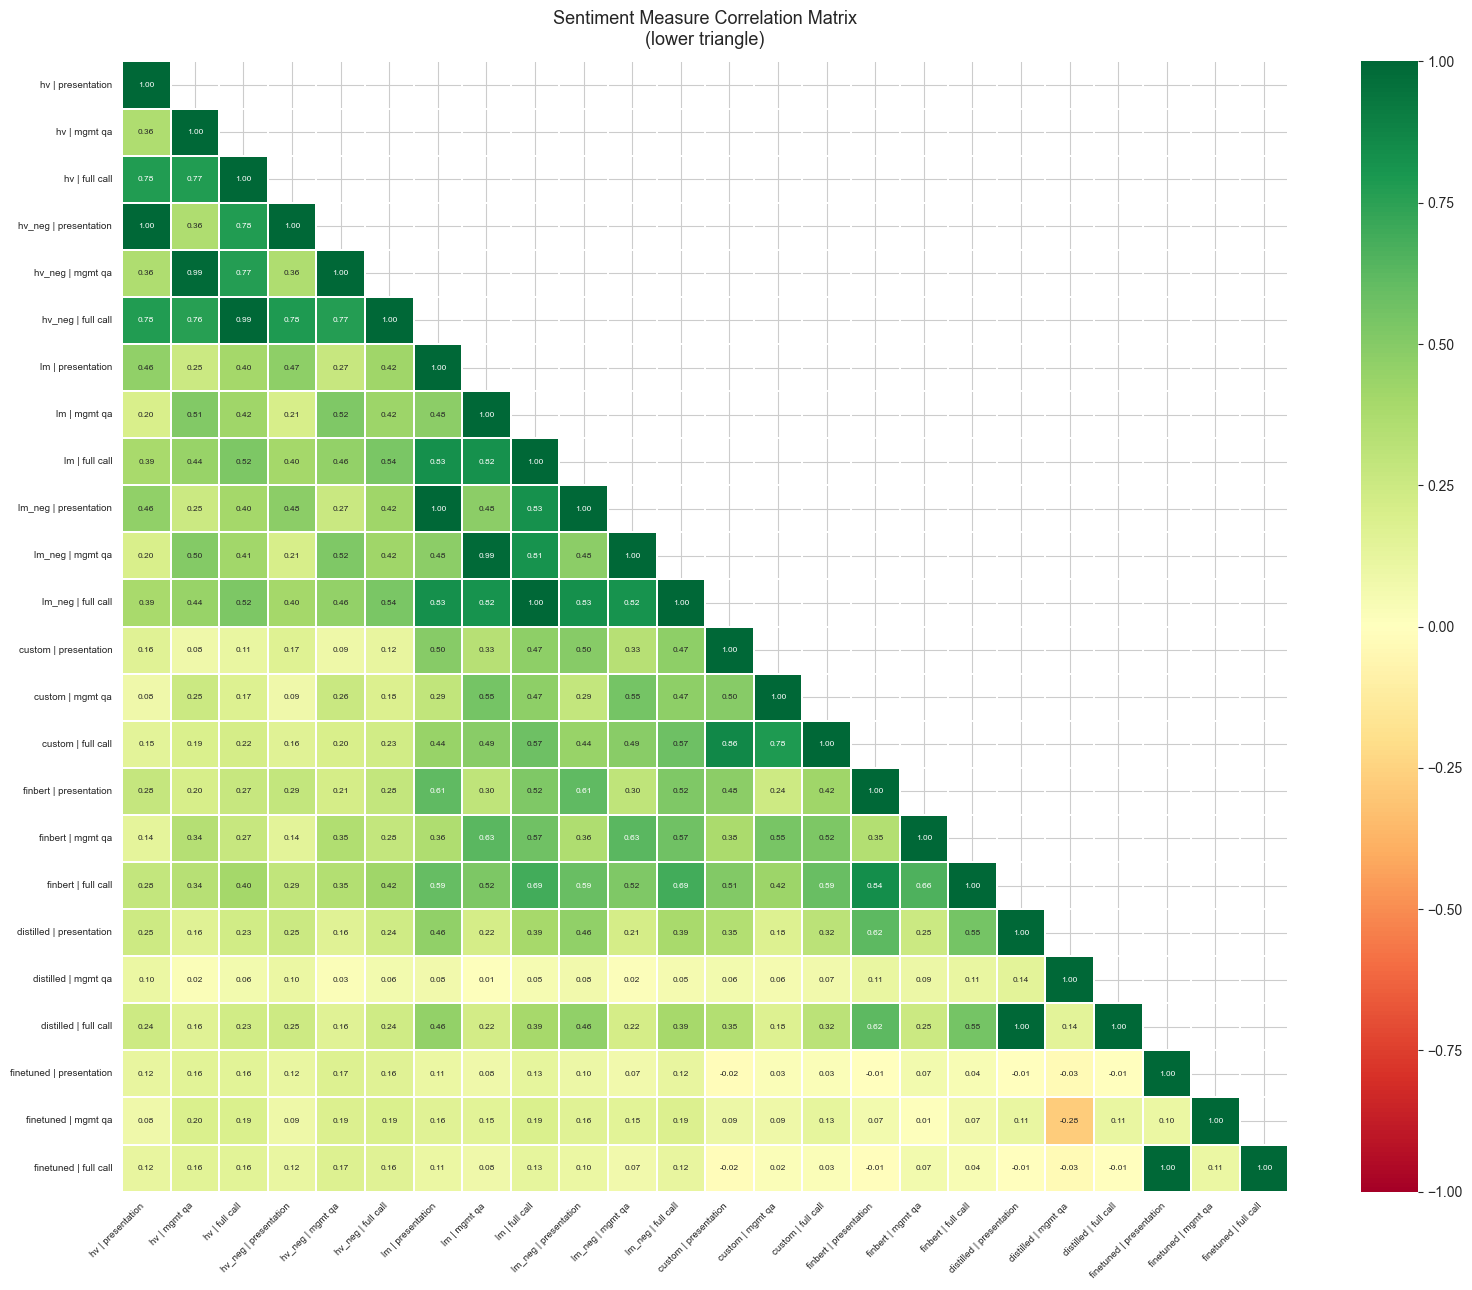

Saved: fig_sent_correlation_matrix.png


In [19]:
# Pretty labels: "sent_lm_neg_full_call" to "lm_neg | full_call"
def pretty(col):
    parts = col.replace('sent_', '').rsplit('_', 1)   # split off unit suffix
    # unit is the last word (presentation / mgmt_qa / full_call)
    for suffix in ['_presentation', '_mgmt_qa', '_full_call']:
        if col.endswith(suffix):
            method = col.replace('sent_', '').replace(suffix, '')
            unit   = suffix.lstrip('_').replace('_', ' ')
            return f'{method} | {unit}'
    return col.replace('sent_', '')

labels = [pretty(c) for c in sent_cols]

# Sort columns: group by method so same methods cluster together
method_order = ['hv', 'hv_neg', 'lm', 'lm_neg', 'custom',
                'finbert', 'distilled', 'finetuned']
unit_order   = ['presentation', 'mgmt_qa', 'full_call']

def sort_key(col):
    for i, m in enumerate(method_order):
        for j, u in enumerate(unit_order):
            if col == f'sent_{m}_{u}':
                return (i, j)
    return (99, 99)

sent_cols_sorted = sorted(sent_cols, key=sort_key)
labels_sorted    = [pretty(c) for c in sent_cols_sorted]

corr_matrix = df[sent_cols_sorted].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True     # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 6},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.3,
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    ax=ax
)
ax.set_title('Sentiment Measure Correlation Matrix\n(lower triangle)', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('fig_sent_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_sent_correlation_matrix.png')


## 5.2  Sentiment × CAR correlation bar chart
One bar per sentiment column; colour by text unit.
For finetuned measures only the OOS test subset is used (no NaN rows).

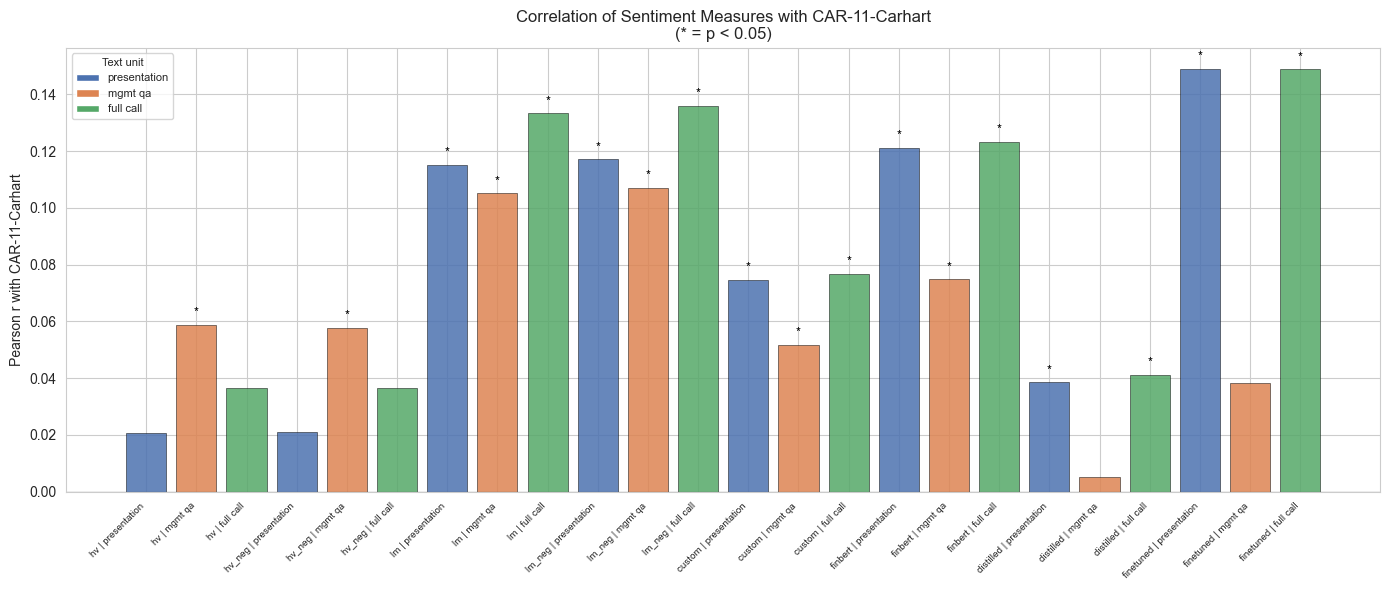

Saved: fig_car_correlations.png


In [20]:
unit_colors = {
    'presentation':'#4C72B0',
    'mgmt_qa':'#DD8452',
    'full_call': '#55A868',
}

def get_unit(col):
    for u in ['presentation', 'mgmt_qa', 'full_call']:
        if col.endswith(u):
            return u
    return 'other'

car_corrs = []
for col in sent_cols_sorted:
    sub = df[[col, TARGET]].dropna()
    if len(sub) < 30:
        car_corrs.append({'col': col, 'r': np.nan, 'p': np.nan, 'n': len(sub)})
        continue
    r, p = stats.pearsonr(sub[col], sub[TARGET])
    car_corrs.append({'col': col, 'r': r, 'p': p, 'n': len(sub)})

car_corr_df = pd.DataFrame(car_corrs)
car_corr_df['label'] = [pretty(c) for c in car_corr_df['col']]
car_corr_df['unit']  = car_corr_df['col'].apply(get_unit)
car_corr_df['color'] = car_corr_df['unit'].map(unit_colors)
car_corr_df['sig']   = car_corr_df['p'] < 0.05     # mark significant bars

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    range(len(car_corr_df)),
    car_corr_df['r'],
    color=car_corr_df['color'],
    edgecolor='black', linewidth=0.4,
    alpha=0.85
)

# Star significant bars
for i, row in car_corr_df.iterrows():
    if row['sig'] and not np.isnan(row['r']):
        ax.text(i, row['r'] + (0.002 if row['r'] >= 0 else -0.005),
                '*', ha='center', va='bottom', fontsize=9, color='black')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(car_corr_df)))
ax.set_xticklabels(car_corr_df['label'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Pearson r with CAR-11-Carhart')
ax.set_title('Correlation of Sentiment Measures with CAR-11-Carhart\n(* = p < 0.05)', fontsize=12)

# Legend for text units
legend_elements = [Patch(facecolor=c, label=u.replace('_', ' '))
                   for u, c in unit_colors.items()]
ax.legend(handles=legend_elements, title='Text unit', fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.savefig('fig_car_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# Print ranked table
print('\n=== Sentiment × CAR-11-Carhart correlations (ranked by |r|) ===')
print(car_corr_df[['label', 'r', 'p', 'n']]
      .dropna(subset=['r'])
      .assign(abs_r=lambda x: x['r'].abs())
      .sort_values('abs_r', ascending=False)
      .drop(columns='abs_r')
      .to_string(index=False, float_format='{:.4f}'.format))



=== Sentiment × CAR-11-Carhart correlations (ranked by |r|) ===
                   label      r      p    n
finetuned | presentation 0.1490 0.0004  564
   finetuned | full call 0.1488 0.0004  564
      lm_neg | full call 0.1361 0.0000 2817
          lm | full call 0.1333 0.0000 2817
     finbert | full call 0.1233 0.0000 2817
  finbert | presentation 0.1212 0.0000 2817
   lm_neg | presentation 0.1171 0.0000 2817
       lm | presentation 0.1151 0.0000 2817
        lm_neg | mgmt qa 0.1071 0.0000 2817
            lm | mgmt qa 0.1051 0.0000 2817
      custom | full call 0.0769 0.0000 2817
       finbert | mgmt qa 0.0748 0.0001 2817
   custom | presentation 0.0747 0.0001 2817
            hv | mgmt qa 0.0588 0.0018 2817
        hv_neg | mgmt qa 0.0577 0.0022 2817
        custom | mgmt qa 0.0518 0.0060 2817
   distilled | full call 0.0413 0.0285 2817
distilled | presentation 0.0385 0.0410 2817
     finetuned | mgmt qa 0.0381 0.3662  564
      hv_neg | full call 0.0367 0.0515 2817
          h

## 5.3  Sentiment × control variables
Shows whether high-sentiment calls coincide with strong earnings surprises
(important to verify that sentiment adds info beyond just the surprise).

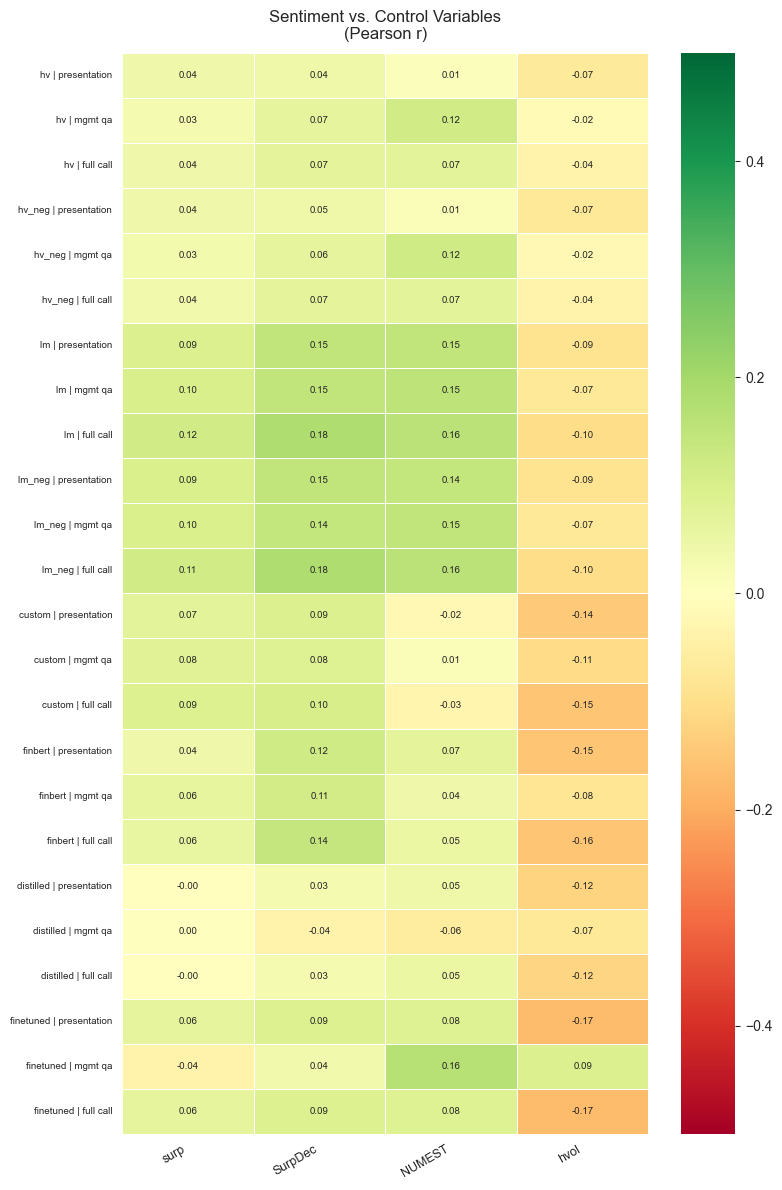

Saved: fig_sent_vs_controls.png


In [22]:
avail_controls = [c for c in CONTROLS if c in df.columns]
ctrl_corr = (
    df[sent_cols_sorted + avail_controls]
    .corr()
    .loc[sent_cols_sorted, avail_controls]
)
ctrl_corr.index = labels_sorted

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    ctrl_corr,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.4,
    ax=ax
)
ax.set_title('Sentiment vs. Control Variables\n(Pearson r)', fontsize=12, pad=10)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('fig_sent_vs_controls.png', dpi=150, bbox_inches='tight')
plt.show()


## 5.4  Summary table: best measure per text unit

In [23]:
print('\n=== Best sentiment measure per text unit (highest |r| with CAR) ===')
for unit in ['presentation', 'mgmt_qa', 'full_call']:
    unit_rows = car_corr_df[car_corr_df['unit'] == unit].dropna(subset=['r'])
    if unit_rows.empty:
        continue
    best = unit_rows.loc[unit_rows['r'].abs().idxmax()]
    print(f"  {unit:<16}  best: {best['label']:<35}  r={best['r']:+.4f}  p={best['p']:.4f}")



=== Best sentiment measure per text unit (highest |r| with CAR) ===
  presentation      best: finetuned | presentation             r=+0.1490  p=0.0004
  mgmt_qa           best: lm_neg | mgmt qa                     r=+0.1071  p=0.0000
  full_call         best: finetuned | full call                r=+0.1488  p=0.0004

5 Correlation analysis complete.


# 6. Univariate Regressions vs. CAR-11-Carhart
$CAR-11-Carhart_i = α + β · sentiment_i + ε_i$

Saving the coefficient, t-stat, p-value, and R^2.
Sub-analyses:
*   6.1  Run all univariate regressions to master results table
*   6.2  Coefficient plot (β with 95% CI) one panel per text unit
*   6.3  R^2 comparison bar chart which method explains most variance?
*   6.4  Scatter plots for top-3 measures (fitted line + confidence band)


In [24]:


TARGET    = 'CAR-11-Carhart'
sent_cols = [c for c in df.columns if c.startswith('sent_')]


## 6.1  Univariate OLS for every sentiment column

In [25]:
def run_univariate_ols(df, sentiment_col, target_col):
    """
    Fit CAR ~ const + sentiment.
    Returns dict with key regression statistics.
    Standardises the sentiment column (z-score) so coefficients are comparable
    across measures with different natural scales.
    """
    sub = df[[sentiment_col, target_col]].dropna()
    if len(sub) < 50:
        return None                         # skip if too few observations

    # Standardise sentiment (mean=0, std=1) for comparable betas
    x_raw  = sub[sentiment_col]
    x_std  = (x_raw - x_raw.mean()) / x_raw.std()
    y      = sub[target_col]

    X = sm.add_constant(x_std)
    res = sm.OLS(y, X).fit(cov_type='HC3')  # heteroskedasticity-robust SEs

    return {
        'sentiment': sentiment_col,
        'label': pretty(sentiment_col),
        'unit': get_unit(sentiment_col),
        'method': sentiment_col.replace('sent_', '').rsplit('_', 1)[0]
                      if not any(sentiment_col.endswith(u)
                                 for u in ['_presentation','_mgmt_qa','_full_call'])
                      else sentiment_col.replace('sent_', '').replace(
                          '_' + get_unit(sentiment_col), ''),
        'n': len(sub),
        'beta':  res.params.iloc[1],
        'se': res.bse.iloc[1],
        't_stat': res.tvalues.iloc[1],
        'p_value': res.pvalues.iloc[1],
        'r2': res.rsquared,
        'r2_adj': res.rsquared_adj,
        'significant': res.pvalues.iloc[1] < 0.05,
    }

print('Running univariate OLS regressions...')
results = [run_univariate_ols(df, col, TARGET) for col in sent_cols]
results = [r for r in results if r is not None]
reg_df  = pd.DataFrame(results).sort_values('r2', ascending=False)

print('\n=== Univariate OLS: CAR-11-Carhart ~ sentiment (standardised β) ===')
print(f"{'Label':<40} {'β':>8} {'t':>7} {'p':>7} {'R^2':>7} {'N':>6}")
print('-' * 80)
for _, row in reg_df.iterrows():
    sig = '**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else '  ')
    print(f"{row['label']:<40} {row['beta']:>+8.4f} {row['t_stat']:>7.2f} "
          f"{row['p_value']:>7.4f} {row['r2']:>7.4f} {int(row['n']):>6}  {sig}")

reg_df.to_csv('univariate_regression_results.csv', index=False)


Running univariate OLS regressions...

=== Univariate OLS: CAR-11-Carhart ~ sentiment (standardised β) ===
Label                                           β       t       p     R^2      N
--------------------------------------------------------------------------------
finetuned | presentation                  +0.0089    3.42  0.0006  0.0222    564  **
finetuned | full call                     +0.0089    3.41  0.0006  0.0222    564  **
lm_neg | full call                        +0.0083    7.20  0.0000  0.0185   2817  **
lm | full call                            +0.0081    7.09  0.0000  0.0178   2817  **
finbert | full call                       +0.0075    6.89  0.0000  0.0152   2817  **
finbert | presentation                    +0.0074    6.60  0.0000  0.0147   2817  **
lm_neg | presentation                     +0.0071    6.29  0.0000  0.0137   2817  **
lm | presentation                         +0.0070    6.20  0.0000  0.0132   2817  **
lm_neg | mgmt qa                          +0.0065  

## 6.2  Coefficient plot, β ± 1.96·SE, one panel per text unit

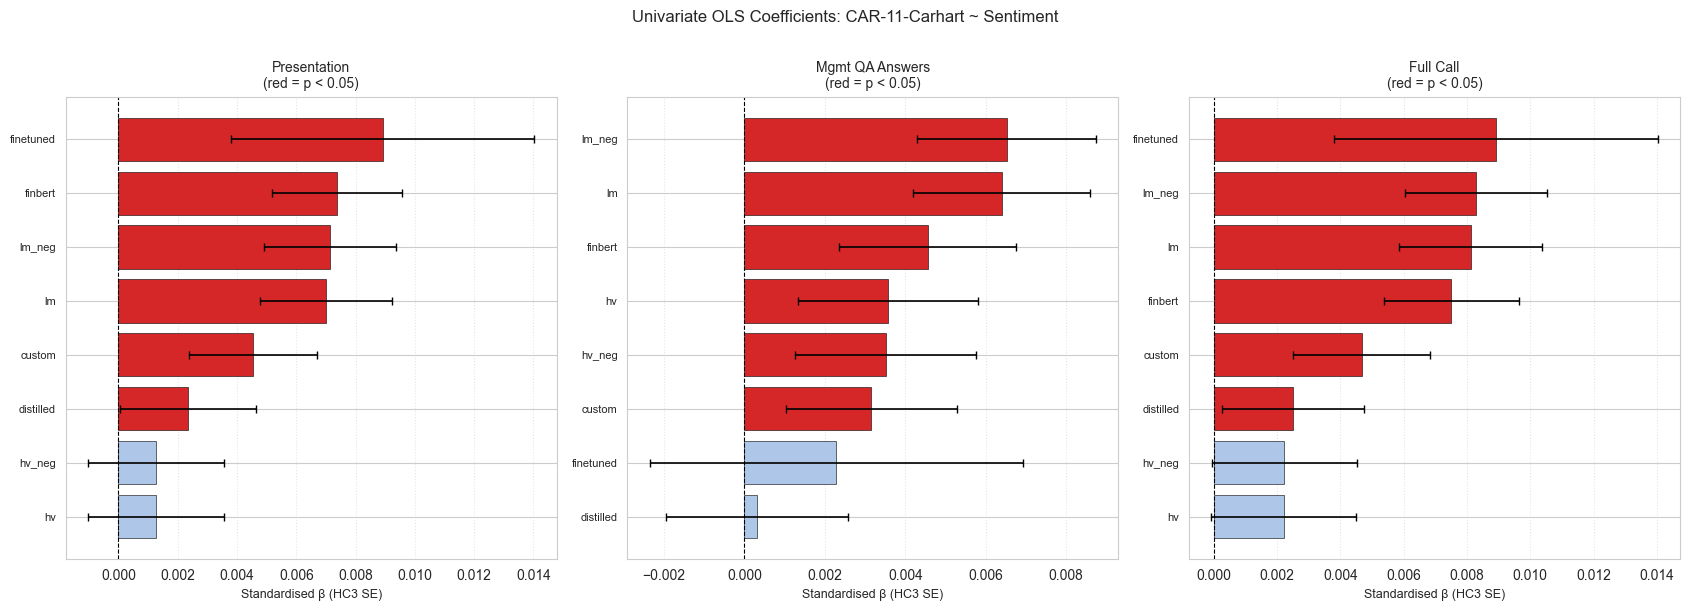

Saved: fig_coef_plot.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)
unit_list = ['presentation', 'mgmt_qa', 'full_call']
unit_titles = ['Presentation', 'Mgmt QA Answers', 'Full Call']

for ax, unit, title in zip(axes, unit_list, unit_titles):
    sub = reg_df[reg_df['unit'] == unit].sort_values('beta', ascending=True)
    if sub.empty:
        ax.set_visible(False)
        continue

    y_pos  = range(len(sub))
    colors = ['#d62728' if s else '#aec7e8' for s in sub['significant']]

    ax.barh(y_pos, sub['beta'], xerr=1.96 * sub['se'],
            color=colors, edgecolor='black', linewidth=0.4,
            error_kw={'elinewidth': 1.2, 'capsize': 3, 'ecolor': 'black'})
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(
        [r['method'] for _, r in sub.iterrows()], fontsize=8
    )
    ax.set_xlabel('Standardised β (HC3 SE)', fontsize=9)
    ax.set_title(f'{title}\n(red = p < 0.05)', fontsize=10)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

fig.suptitle('Univariate OLS Coefficients: CAR-11-Carhart ~ Sentiment',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_coef_plot.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.3  R^2 bar chart; all measures ranked, coloured by method family

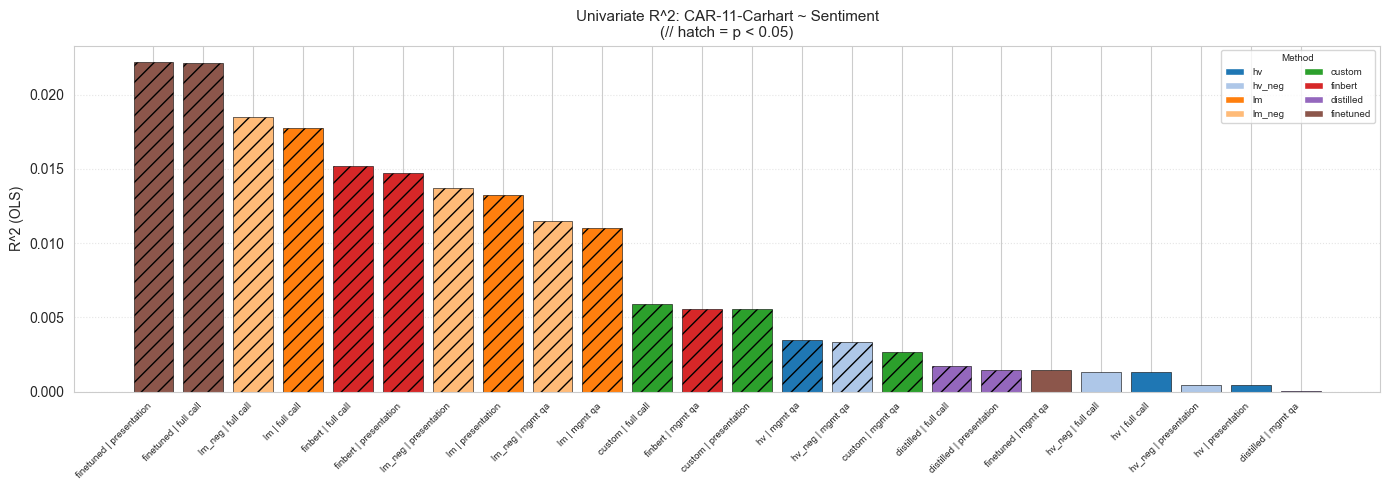

Saved: fig_r2_comparison.png


In [27]:
method_family_colors = {
    'hv': '#1f77b4',
    'hv_neg': '#aec7e8',
    'lm': '#ff7f0e',
    'lm_neg': '#ffbb78',
    'custom': '#2ca02c',
    'finbert': '#d62728',
    'distilled': '#9467bd',
    'finetuned': '#8c564b',
}

def get_method(col):
    for suffix in ['_presentation', '_mgmt_qa', '_full_call']:
        if col.endswith(suffix):
            return col.replace('sent_', '').replace(suffix, '')
    return col.replace('sent_', '')

reg_df['method_key'] = reg_df['sentiment'].apply(get_method)
reg_df['bar_color']  = reg_df['method_key'].map(
    lambda m: method_family_colors.get(m, '#7f7f7f')
)

fig, ax = plt.subplots(figsize=(14, 5))
r2_sorted = reg_df.sort_values('r2', ascending=False).reset_index(drop=True)

bars = ax.bar(
    range(len(r2_sorted)), r2_sorted['r2'],
    color=r2_sorted['bar_color'],
    edgecolor='black', linewidth=0.4
)
# Hatch significant bars
for i, (_, row) in enumerate(r2_sorted.iterrows()):
    if row['significant']:
        bars[i].set_hatch('//')

ax.set_xticks(range(len(r2_sorted)))
ax.set_xticklabels(r2_sorted['label'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('R^2 (OLS)')
ax.set_title('Univariate R^2: CAR-11-Carhart ~ Sentiment\n(// hatch = p < 0.05)', fontsize=11)

# Method-family legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=m)
                  for m, c in method_family_colors.items()]
ax.legend(handles=legend_handles, title='Method', fontsize=7,
          title_fontsize=7, loc='upper right', ncol=2)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.4  Scatter plots for top-3 measures (highest R^2)

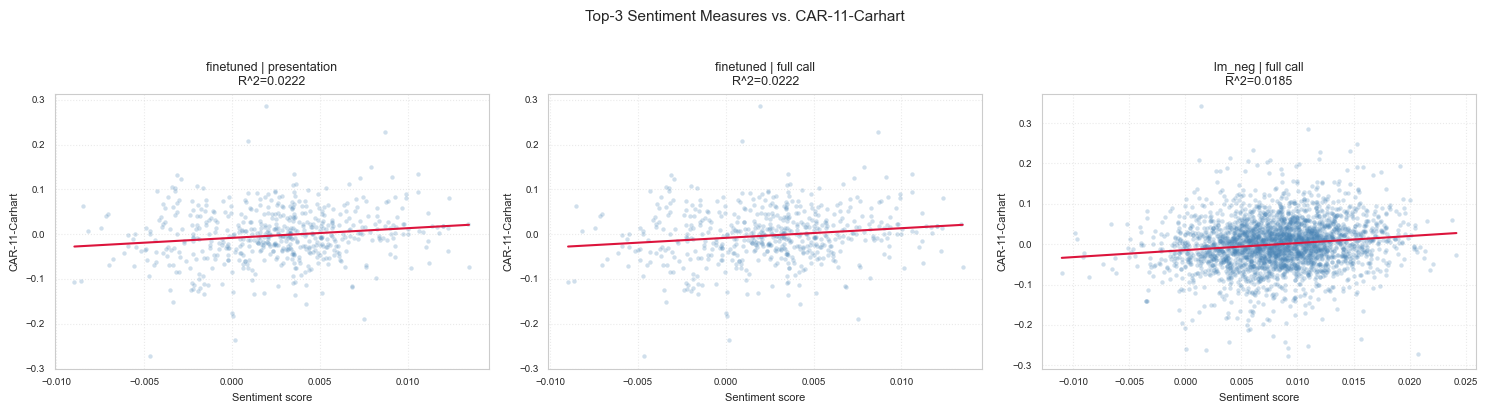

Saved: fig_top3_scatter.png


In [28]:
top3 = reg_df.head(3)['sentiment'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, top3):
    sub = df[[col, TARGET]].dropna()
    x = sub[col]
    y = sub[TARGET]

    ax.scatter(x, y, alpha=0.25, s=10, color='steelblue', linewidths=0)

    # OLS fitted line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)

    r2_val = reg_df.loc[reg_df['sentiment'] == col, 'r2'].values[0]
    ax.set_title(f'{pretty(col)}\nR^2={r2_val:.4f}', fontsize=9)
    ax.set_xlabel('Sentiment score', fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(linestyle=':', alpha=0.4)

plt.suptitle('Top-3 Sentiment Measures vs. CAR-11-Carhart', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_top3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.5  Summary: best overall and best per method family

In [29]:
print('\n=== Top-5 measures by R^2 ===')
print(reg_df[['label', 'beta', 't_stat', 'p_value', 'r2', 'n']]
      .head(5).to_string(index=False, float_format='{:.4f}'.format))

print('\n=== Best measure per method family ===')
best_per_family = (reg_df.sort_values('r2', ascending=False)
                         .groupby('method_key').first()
                         .sort_values('r2', ascending=False)
                         [['label', 'beta', 't_stat', 'p_value', 'r2']])
print(best_per_family.to_string(float_format='{:.4f}'.format))



=== Top-5 measures by R^2 ===
                   label   beta  t_stat  p_value     r2    n
finetuned | presentation 0.0089  3.4152   0.0006 0.0222  564
   finetuned | full call 0.0089  3.4105   0.0006 0.0222  564
      lm_neg | full call 0.0083  7.2037   0.0000 0.0185 2817
          lm | full call 0.0081  7.0854   0.0000 0.0178 2817
     finbert | full call 0.0075  6.8894   0.0000 0.0152 2817

=== Best measure per method family ===
                               label   beta  t_stat  p_value     r2
method_key                                                         
finetuned   finetuned | presentation 0.0089  3.4152   0.0006 0.0222
lm_neg            lm_neg | full call 0.0083  7.2037   0.0000 0.0185
lm                    lm | full call 0.0081  7.0854   0.0000 0.0178
finbert          finbert | full call 0.0075  6.8894   0.0000 0.0152
custom            custom | full call 0.0047  4.2439   0.0000 0.0059
hv                      hv | mgmt qa 0.0036  3.1261   0.0018 0.0035
hv_neg             

# 7. Controlled Regressions

Goal: isolate the incremental predictive value of sentiment BEYOND what
is already captured by hard financial information (earnings surprise,
analyst coverage, volatility).

Three model specifications per sentiment measure:
* M1 (baseline):    CAR ~ controls only
* M2 (sentiment):   CAR ~ sentiment only          (= 6 results)
* M3 (full):        CAR ~ controls + sentiment

 Key metric: ΔR^2 = R^2(M3) − R^2(M1)
   to how much additional variance does sentiment explain over controls?

Sub-analyses:
*   7.1  Define control set & check availability
*   7.2  Run M1 baseline once (all controls, full sample)
*   7.3  Run M3 for every sentiment column to ΔR^2 table
*   7.4  deltaR^2 bar chart ranked by incremental explanatory power
*   7.5  Detailed regression tables for top-5 measures (publication-style)
*   7.6  Text-unit comparison: which section adds most incremental info?



In [30]:
TARGET = 'CAR-11-Carhart'

## 7.1  Control variable set
* surp / SurpDec : earnings surprise (hard fundamental signal)
* NUMEST : analyst coverage (information environment proxy)
* hvol : historical volatility (risk / uncertainty proxy)

We standardise all controls for comparability.

In [31]:
ALL_CONTROLS = ['surp', 'SurpDec', 'NUMEST', 'hvol']
CONTROLS = [c for c in ALL_CONTROLS if c in df.columns]
print(f'Controls available: {CONTROLS}')

def standardise(series):
    """Z-score normalise, return series with same index."""
    mu, sigma = series.mean(), series.std()
    return (series - mu) / sigma if sigma > 0 else series - mu

sent_cols = [c for c in df.columns if c.startswith('sent_')]



Controls available: ['surp', 'SurpDec', 'NUMEST', 'hvol']


## 7.2  Baseline M1: CAR ~ controls only
Fit on the largest common sample (all rows where controls + CAR present)

In [32]:
base_cols = CONTROLS + [TARGET]
df_base   = df[base_cols].dropna()

X_base = sm.add_constant(df_base[CONTROLS].apply(standardise))
m1     = sm.OLS(df_base[TARGET], X_base).fit(cov_type='HC3')
R2_M1  = m1.rsquared

print(f'\nM1 (controls only):  N={len(df_base):,}  R^2={R2_M1:.4f}')
m1.summary2()


M1 (controls only):  N=2,773  R^2=0.0771


<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.076     
Dependent Variable: CAR-11-Carhart   AIC:                -7884.5810
Date:               2026-04-10 18:26 BIC:                -7854.9426
No. Observations:   2773             Log-Likelihood:     3947.3    
Df Model:           4                F-statistic:        46.19     
Df Residuals:       2768             Prob (F-statistic): 1.26e-37  
R-squared:          0.077            Scale:              0.0034033 
---------------------------------------------------------------------
             Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
---------------------------------------------------------------------
const       -0.0005     0.0011   -0.4306   0.6667   -0.0027    0.0017
surp        -0.0035     0.0018   -1.9050   0.0568   -0.0070    0.0001
SurpDec      0.0174     0.0016   10.8871   0.0000    0.0142    0.0205
NUMEST       0.0010     0.0012    0.8433   0.3991   -0.0013    0.0033
hvol        -0.0058     0.0023   -2.4738   0.0134   -0.0103   -0.0012
-------------------------------------------------------------------
Omnibus:              186.825       Durbin-Watson:          2.119  
Prob(Omnibus):        0.000         Jarque-Bera (JB):       604.984
Skew:                 0.300         Prob(JB):               0.000  
Kurtosis:             5.208         Condition No.:          2      
===================================================================
Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 7.3  M3: CAR ~ controls + sentiment  for every sentiment column

In [33]:
def run_controlled_ols(df, sentiment_col, target_col, control_cols):
    """
    Fit two regressions:
        M1_sub : target ~ controls          (on the sentiment-available sample)
        M3     : target ~ controls + sentiment
    Returns dict with incremental stats vs. M1_sub.
    Using the same sample for M1_sub and M3 ensures deltaR^2 is meaningful.
    """
    cols_needed = [sentiment_col, target_col] + control_cols
    sub = df[cols_needed].dropna()
    if len(sub) < 50:
        return None

    y = sub[target_col]
    sent_std = standardise(sub[sentiment_col])
    ctrl_std = sub[control_cols].apply(standardise)

    # M1 on the matched sample
    X_m1 = sm.add_constant(ctrl_std)
    m1_s = sm.OLS(y, X_m1).fit(cov_type='HC3')

    # M3: controls + sentiment
    X_m3 = sm.add_constant(pd.concat([ctrl_std, sent_std], axis=1))
    m3 = sm.OLS(y, X_m3).fit(cov_type='HC3')

    return {
        'sentiment': sentiment_col,
        'label': pretty(sentiment_col),
        'unit': get_unit(sentiment_col),
        'method_key': get_method(sentiment_col),
        'n': len(sub),
        # M1 sub-sample stats
        'r2_m1': m1_s.rsquared,
        # M3 stats
        'r2_m3': m3.rsquared,
        'delta_r2': m3.rsquared - m1_s.rsquared,
        # Sentiment coefficient in M3
        'beta_m3': m3.params[sentiment_col],
        'se_m3': m3.bse[sentiment_col],
        't_m3': m3.tvalues[sentiment_col],
        'p_m3': m3.pvalues[sentiment_col],
        'sig': m3.pvalues[sentiment_col] < 0.05,
        # Keep full model object for table printing
        '_m3_model': m3,
        '_m1_model': m1_s,
    }




Running controlled regressions (M3)...


In [34]:
print('\Running controlled regressions (M3)...')

ctrl_results = [run_controlled_ols(df, col, TARGET, CONTROLS) for col in sent_cols]
ctrl_results = [r for r in ctrl_results if r is not None]
ctrl_df = pd.DataFrame([{k: v for k, v in r.items()
                               if not k.startswith('_')}
                              for r in ctrl_results])
ctrl_df = ctrl_df.sort_values('delta_r2', ascending=False)

print('\n=== M3 Controlled Regressions: deltaR^2 = R^2(controls+sentiment) − R^2(controls) ===')
print(f"{'Label':<40} {'β_sent':>8} {'t':>7} {'p':>7} "
      f"{'R^2_M1':>7} {'R^2_M3':>7} {'deltaR^2':>8}")
print('-' * 92)
for _, row in ctrl_df.iterrows():
    sig = '**' if row['p_m3'] < 0.01 else ('*' if row['p_m3'] < 0.05 else '  ')
    print(f"{row['label']:<40} {row['beta_m3']:>+8.4f} {row['t_m3']:>7.2f} "
          f"{row['p_m3']:>7.4f} {row['r2_m1']:>7.4f} {row['r2_m3']:>7.4f} "
          f"{row['delta_r2']:>8.5f}  {sig}")

ctrl_df.to_csv('controlled_regression_results.csv', index=False)



=== M3 Controlled Regressions: deltaR^2 = R^2(controls+sentiment) − R^2(controls) ===
Label                                      β_sent       t       p  R^2_M1  R^2_M3 deltaR^2
--------------------------------------------------------------------------------------------
finetuned | presentation                  +0.0056    2.10  0.0354  0.1096  0.1179  0.00829  *
finetuned | full call                     +0.0056    2.10  0.0359  0.1096  0.1178  0.00824  *
lm_neg | full call                        +0.0050    4.30  0.0000  0.0771  0.0835  0.00638  **
lm | full call                            +0.0049    4.17  0.0000  0.0771  0.0831  0.00599  **
finbert | presentation                    +0.0046    4.18  0.0000  0.0771  0.0826  0.00552  **
finbert | full call                       +0.0044    4.17  0.0000  0.0771  0.0822  0.00512  **
lm_neg | presentation                     +0.0043    3.73  0.0002  0.0771  0.0818  0.00474  **
lm | presentation                         +0.0042    3.65  0.0003 

## 7.4  deltaR^2 bar chart , ranked, coloured by method family

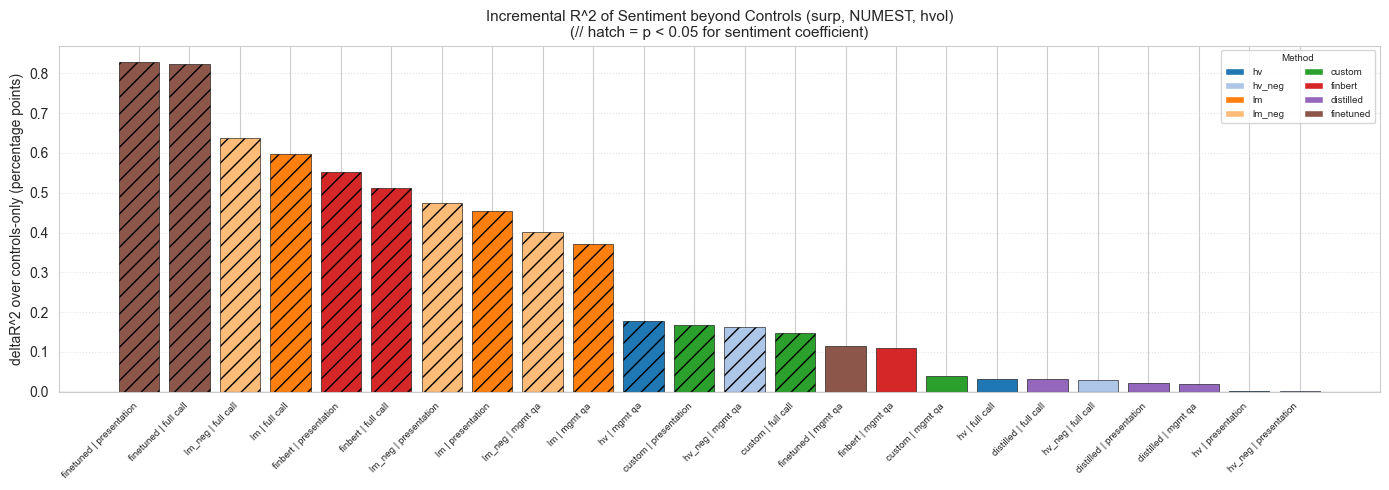

Saved: fig_delta_r2.png


In [35]:
ctrl_df['bar_color'] = ctrl_df['method_key'].map(
    lambda m: method_family_colors.get(m, '#7f7f7f')
)

fig, ax = plt.subplots(figsize=(14, 5))
dr2_sorted = ctrl_df.sort_values('delta_r2', ascending=False).reset_index(drop=True)

bars = ax.bar(
    range(len(dr2_sorted)), dr2_sorted['delta_r2'] * 100,   # as % points
    color=dr2_sorted['bar_color'],
    edgecolor='black', linewidth=0.4
)
for i, (_, row) in enumerate(dr2_sorted.iterrows()):
    if row['sig']:
        bars[i].set_hatch('//')

ax.set_xticks(range(len(dr2_sorted)))
ax.set_xticklabels(dr2_sorted['label'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('deltaR^2 over controls-only (percentage points)')
ax.set_title(
    'Incremental R^2 of Sentiment beyond Controls (surp, NUMEST, hvol)\n'
    '(// hatch = p < 0.05 for sentiment coefficient)', fontsize=11
)
legend_handles = [Patch(facecolor=c, label=m)
                  for m, c in method_family_colors.items()]
ax.legend(handles=legend_handles, title='Method', fontsize=7,
          title_fontsize=7, loc='upper right', ncol=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_delta_r2.png', dpi=150, bbox_inches='tight')
plt.show()


## 7.5  Regression tables for top-5 measures
Columns: M1 | M3_top1 | M3_top2 | M3_top3 | M3_top4 | M3_top5

In [36]:
top5_rows = ctrl_df.head(5)
top5_cols = top5_rows['sentiment'].tolist()
top5_results = {r['sentiment']: r for r in ctrl_results
                if r['sentiment'] in top5_cols}

# Build a combined coefficient table (rows = variables, cols = models)
def fmt_coef(val, pval):
    stars = '***' if pval < 0.001 else ('**' if pval < 0.01
            else ('*' if pval < 0.05 else ''))
    return f'{val:+.4f}{stars}'

def fmt_se(val):
    return f'({val:.4f})'

row_vars = CONTROLS + ['sentiment', 'const']
col_names = ['M1 (controls)'] + [pretty(c) for c in top5_cols]
table = {col: {} for col in col_names}

# M1 baseline (full sample)
for var in CONTROLS + ['const']:
    if var in m1.params.index:
        table['M1 (controls)'][var]        = fmt_coef(m1.params[var], m1.pvalues[var])
        table['M1 (controls)'][var + '_se']= fmt_se(m1.bse[var])
table['M1 (controls)']['N']  = str(len(df_base))
table['M1 (controls)']['R^2'] = f"{m1.rsquared:.4f}"

# M3 models
for col in top5_cols:
    r   = top5_results[col]
    m3  = r['_m3_model']
    m1s = r['_m1_model']
    lbl = pretty(col)

    for var in CONTROLS + ['const']:
        if var in m3.params.index:
            table[lbl][var]         = fmt_coef(m3.params[var], m3.pvalues[var])
            table[lbl][var + '_se'] = fmt_se(m3.bse[var])

    # Sentiment row uses the actual column name as key in params
    table[lbl]['sentiment'] = fmt_coef(r['beta_m3'], r['p_m3'])
    table[lbl]['sentiment_se'] = fmt_se(r['se_m3'])
    table[lbl]['N'] = str(r['n'])
    table[lbl]['R^2(M1)'] = f"{r['r2_m1']:.4f}"
    table[lbl]['R^2(M3)'] = f"{r['r2_m3']:.4f}"
    table[lbl]['deltaR^2'] = f"{r['delta_r2']:.5f}"

print_rows = []
for var in CONTROLS:
    print_rows += [var, var + '_se']
print_rows += ['sentiment', 'sentiment_se', 'const', 'const_se',
               'N', 'R^2', 'R^2(M1)', 'R^2(M3)', 'deltaR^2']

pub_table = pd.DataFrame(table, index=print_rows).fillna('')
print('\n=== Regression table (top-5 sentiment measures) ===')
print(pub_table.to_string())
pub_table.to_csv('publication_regression_table.csv')



=== Regression table (top-5 sentiment measures) ===
             M1 (controls) finetuned | presentation finetuned | full call lm_neg | full call lm | full call finbert | presentation
surp               -0.0035                  -0.0048               -0.0048            -0.0034        -0.0034                -0.0031
surp_se           (0.0018)                 (0.0033)              (0.0033)           (0.0019)       (0.0019)               (0.0018)
SurpDec         +0.0174***               +0.0167***            +0.0167***         +0.0165***     +0.0165***             +0.0167***
SurpDec_se        (0.0016)                 (0.0037)              (0.0037)           (0.0016)       (0.0016)               (0.0016)
NUMEST             +0.0010                  +0.0034               +0.0034            +0.0002        +0.0002                +0.0006
NUMEST_se         (0.0012)                 (0.0024)              (0.0024)           (0.0012)       (0.0012)               (0.0012)
hvol              -0.0058*    

## 7.6  Text-unit comparison; which section adds most incremental R^2?

In [37]:
print('\n=== Incremental R^2 by text unit (mean deltaR^2 across all methods) ===')
unit_summary = (ctrl_df.groupby('unit').agg(
    mean_delta_r2=('delta_r2', 'mean'),
    max_delta_r2 =('delta_r2', 'max'),
    n_significant=('sig', 'sum'),
    n_total =('sig', 'count')
).sort_values('mean_delta_r2', ascending=False))
print(unit_summary.to_string(float_format='{:.5f}'.format))

print('\n=== Best measure per text unit (highest deltaR^2) ===')
for unit in ['presentation', 'mgmt_qa', 'full_call']:
    sub = ctrl_df[ctrl_df['unit'] == unit]
    if sub.empty:
        continue
    best = sub.iloc[0]
    print(f"  {unit:<16}  {best['label']:<40}  "
          f"deltaR^2={best['delta_r2']:.5f}  β={best['beta_m3']:+.4f}  "
          f"p={best['p_m3']:.4f}")

print('\n=== Best measure per method family (highest deltaR^2) ===')
best_family = (ctrl_df.sort_values('delta_r2', ascending=False)
                      .groupby('method_key').first()
                      .sort_values('delta_r2', ascending=False)
                      [['label', 'beta_m3', 't_m3', 'p_m3', 'delta_r2']])

print(best_family.to_string(float_format='{:.4f}'.format))


=== Incremental R^2 by text unit (mean deltaR^2 across all methods) ===
              mean_delta_r2  max_delta_r2  n_significant  n_total
unit                                                             
full_call           0.00352       0.00824              5        8
presentation        0.00313       0.00829              5        8
mgmt_qa             0.00174       0.00402              4        8

=== Best measure per text unit (highest deltaR^2) ===
  presentation      finetuned | presentation                  deltaR^2=0.00829  β=+0.0056  p=0.0354
  mgmt_qa           lm_neg | mgmt qa                          deltaR^2=0.00402  β=+0.0039  p=0.0006
  full_call         finetuned | full call                     deltaR^2=0.00824  β=+0.0056  p=0.0359

=== Best measure per method family (highest deltaR^2) ===
                               label  beta_m3   t_m3   p_m3  delta_r2
method_key                                                           
finetuned   finetuned | presentation   0.00